# 杰瑞股份 (002353.SZ) 量化分析报告

**分析周期**: 2025-07-02 至 2026-07-01 (242个交易日)

**数据来源**: Tushare Pro (通过 MCP 接口)

---

## 1. 环境准备与数据加载

导入所需的 Python 库，加载已经通过 Tushare MCP 获取的日线数据。

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import matplotlib.ticker as ticker
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC', 'Heiti SC']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (16, 9)

print('✅ 环境准备完毕')

✅ 环境准备完毕


In [4]:
# 加载数据
df = pd.read_csv('杰瑞股份_日线.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

print(f'📊 数据概览')
print(f'   时间范围: {df.index[0].strftime("%Y-%m-%d")} ~ {df.index[-1].strftime("%Y-%m-%d")}')
print(f'   交易日数: {len(df)}')
print(f'   起始价: ¥{df["close"].iloc[0]:.2f}')
print(f'   最新价: ¥{df["close"].iloc[-1]:.2f}')
print(f'   最高价: ¥{df["high"].max():.2f}')
print(f'   最低价: ¥{df["low"].min():.2f}')
print(f'   总成交额: ¥{df["amount"].sum()/1e8:.1f}亿')

📊 数据概览
   时间范围: 2025-07-02 ~ 2026-07-01
   交易日数: 242
   起始价: ¥35.06
   最新价: ¥154.64
   最高价: ¥175.50
   最低价: ¥33.67
   总成交额: ¥3.8亿


In [5]:
# 查看前5行和后5行
print('=== 前5个交易日 ===')
display(df.head())
print('\n=== 后5个交易日 ===')
display(df.tail())

=== 前5个交易日 ===
             open   high    low  close  ...  change  pct_chg       vol      amount
date                                    ...                                       
2025-07-02  35.00  35.46  34.88  35.06  ...    0.23   0.6604  66536.54  233817.658
2025-07-03  35.01  35.18  34.08  34.25  ...   -0.81  -2.3103  74906.21  257934.702
2025-07-04  34.10  34.59  34.01  34.52  ...    0.27   0.7883  86662.49  297464.852
2025-07-07  34.44  34.62  33.93  34.00  ...   -0.52  -1.5064  86586.54  295642.718
2025-07-08  34.00  34.55  33.67  34.11  ...    0.11   0.3235  90912.21  310249.394

[5 rows x 9 columns]

=== 后5个交易日 ===
              open    high     low  ...  pct_chg        vol        amount
date                                ...                                  
2026-06-25  159.19  167.99  159.19  ...   2.7460  147621.59  2.421744e+06
2026-06-26  163.00  166.70  160.03  ...  -1.2109  115971.89  1.892203e+06
2026-06-29  163.17  165.63  145.40  ...  -6.7108  268314.13  4.055332e

## 2. 收盘价走势

绘制过去一年的每日收盘价曲线，标注关键价位和涨跌阶段。


📈 总涨幅: 341.07%
   年化收益率: 341.07%


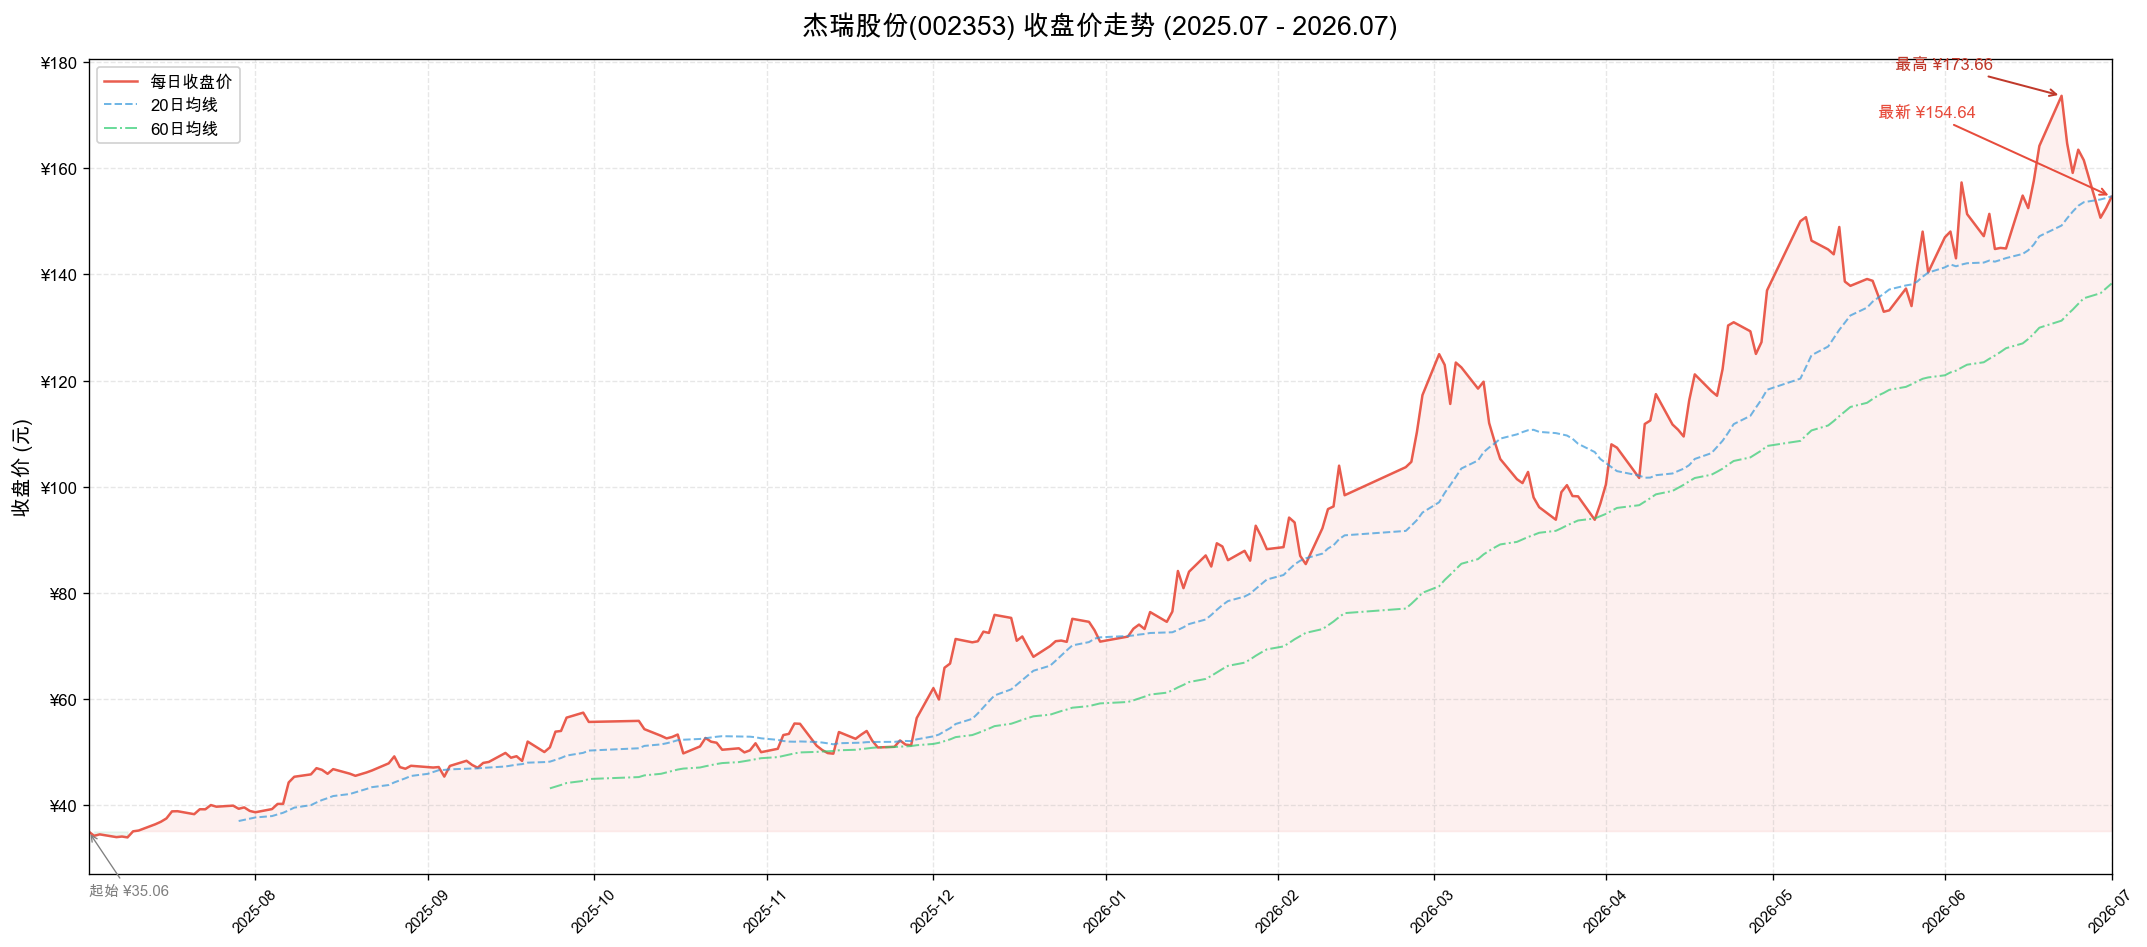

In [7]:
fig, ax = plt.subplots(figsize=(18, 8))

# 主曲线
ax.plot(df.index, df['close'], color='#e74c3c', linewidth=1.5, label='每日收盘价', alpha=0.9)

# 20日移动均线
ma20 = df['close'].rolling(20).mean()
ax.plot(df.index, ma20, color='#3498db', linewidth=1.2, linestyle='--', label='20日均线', alpha=0.7)

# 60日移动均线
ma60 = df['close'].rolling(60).mean()
ax.plot(df.index, ma60, color='#2ecc71', linewidth=1.2, linestyle='-.', label='60日均线', alpha=0.7)

# 填充涨跌区域
ax.fill_between(df.index, df['close'].iloc[0], df['close'],
                where=(df['close'] >= df['close'].iloc[0]),
                color='#e74c3c', alpha=0.08, label='_nolegend_')
ax.fill_between(df.index, df['close'].iloc[0], df['close'],
                where=(df['close'] < df['close'].iloc[0]),
                color='#27ae60', alpha=0.08, label='_nolegend_')

# 标注关键价格
start_price = df['close'].iloc[0]
end_price = df['close'].iloc[-1]
max_idx = df['close'].idxmax()
min_idx = df['close'].idxmin()

ax.annotate(f'起始 ¥{start_price:.2f}', xy=(df.index[0], start_price),
            xytext=(df.index[0], start_price - 12), fontsize=9, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.annotate(f'最新 ¥{end_price:.2f}', xy=(df.index[-1], end_price),
            xytext=(df.index[-30], end_price + 15), fontsize=10, color='#e74c3c',
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2))

ax.annotate(f'最高 ¥{df["close"].max():.2f}', xy=(max_idx, df['close'].max()),
            xytext=(max_idx - pd.Timedelta(days=30), df['close'].max() + 5),
            fontsize=10, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2))

# 格式化
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, fontsize=9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))
ax.set_title('杰瑞股份(002353) 收盘价走势 (2025.07 - 2026.07)', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('收盘价 (元)', fontsize=12)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(df.index[0], df.index[-1])

plt.tight_layout()
plt.show()
print(f'\n📈 总涨幅: {(end_price/start_price - 1)*100:.2f}%')
print(f'   年化收益率: {((end_price/start_price)**(1/1) - 1)*100:.2f}%')

## 3. K线图（蜡烛图）

K线图是技术分析的核心工具，每根K线包含四个价格：开盘价(Open)、最高价(High)、最低价(Low)、收盘价(Close)。
- **红色阳线**: 收盘价 > 开盘价，上涨
- **绿色阴线**: 收盘价 < 开盘价，下跌

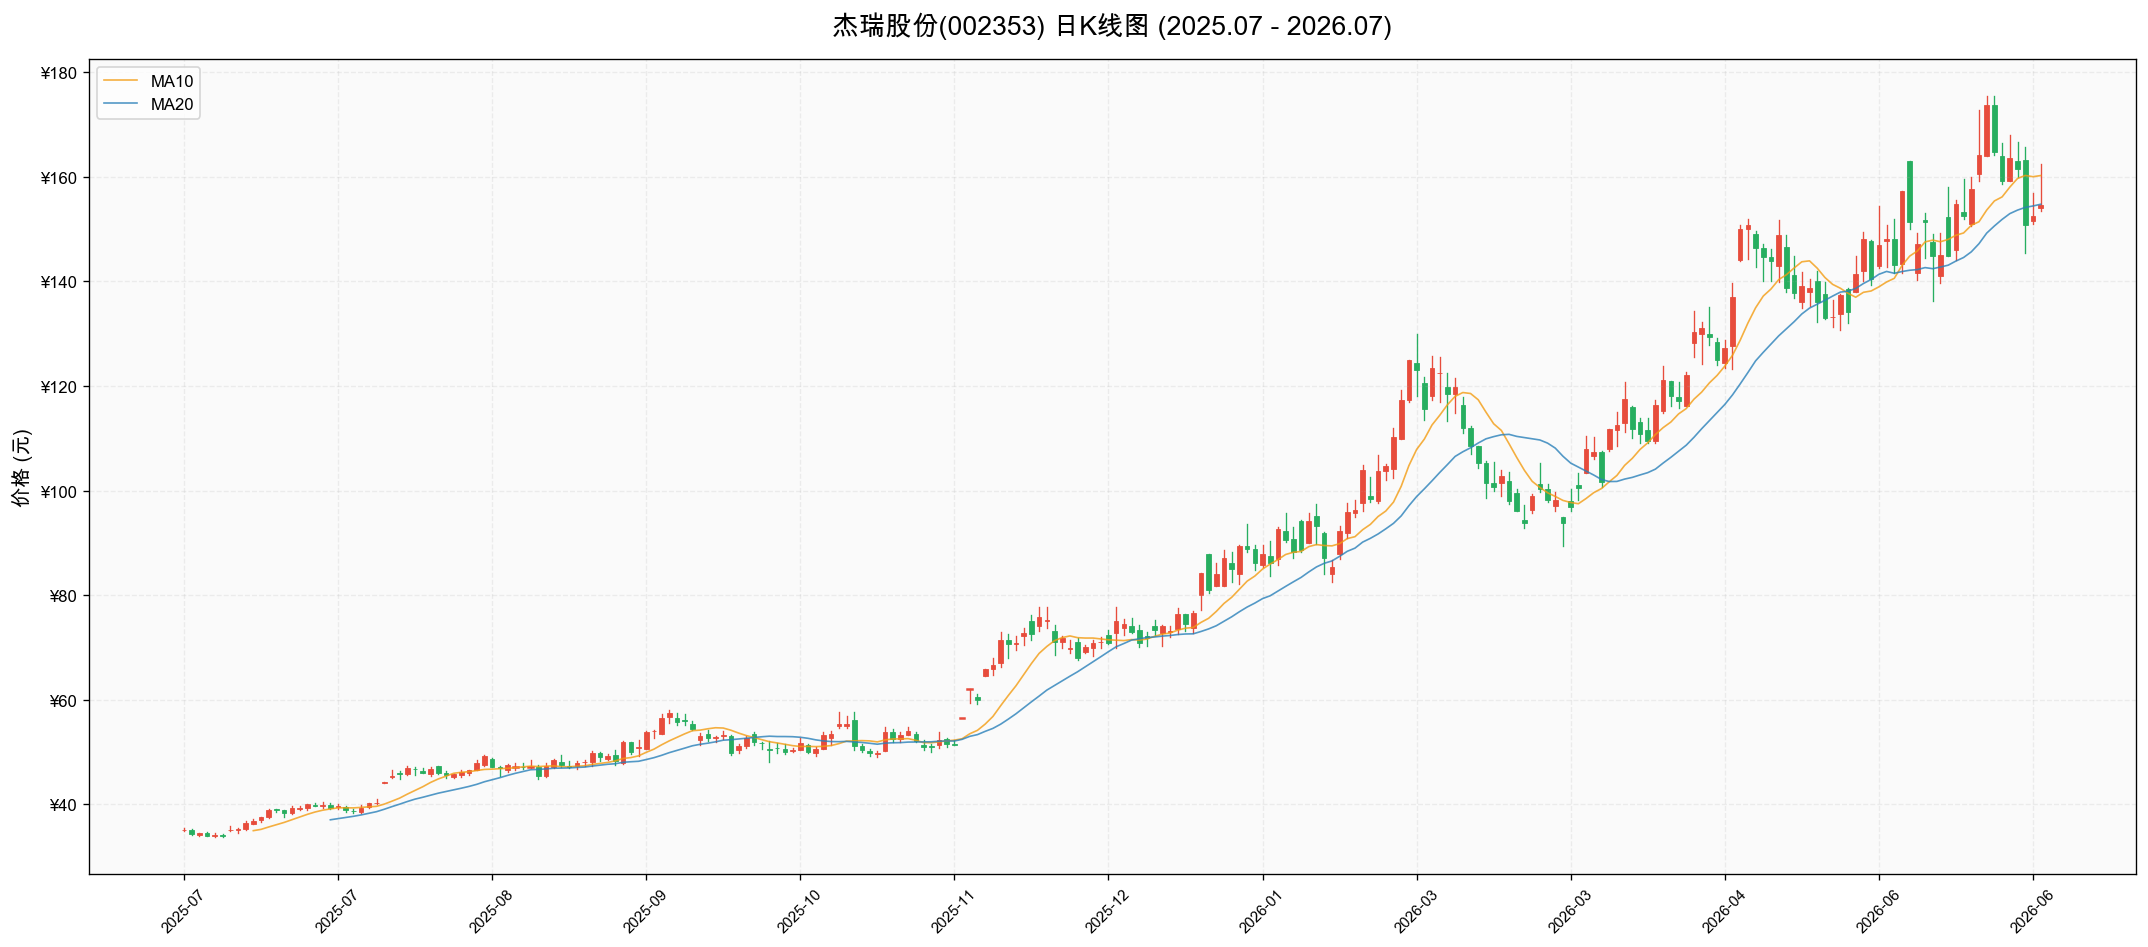

In [9]:
def plot_candlestick(df, title, start=None, end=None):
    """
    绘制K线蜡烛图
    中国股市惯例：涨红跌绿
    """
    data = df.copy()
    if start:
        data = data.loc[start:]
    if end:
        data = data.loc[:end]
    
    fig, ax = plt.subplots(figsize=(18, 8))
    
    # 背景
    ax.set_facecolor('#fafafa')
    
    width = 0.6
    for i, (idx, row) in enumerate(data.iterrows()):
        is_up = row['close'] >= row['open']
        color = '#e74c3c' if is_up else '#27ae60'  # 涨红跌绿（A股惯例）
        
        # 影线
        ax.plot([i, i], [row['low'], row['high']], color=color, linewidth=0.8)
        
        # 实体
        body_bottom = row['open'] if is_up else row['close']
        body_height = abs(row['close'] - row['open'])
        
        if body_height > 0:
            rect = Rectangle((i - width/2, body_bottom), width, body_height,
                            facecolor=color, edgecolor=color, linewidth=0.5)
            ax.add_patch(rect)
        else:
            ax.plot([i - width/2, i + width/2], [row['close'], row['close']],
                   color=color, linewidth=1.5)
    
    # 均线
    x_vals = range(len(data))
    ma10 = data['close'].rolling(10).mean()
    ax.plot(x_vals, ma10.values, color='#f39c12', linewidth=1.0, label='MA10', alpha=0.8)
    ma20 = data['close'].rolling(20).mean()
    ax.plot(x_vals, ma20.values, color='#2980b9', linewidth=1.0, label='MA20', alpha=0.8)
    
    # X轴标签
    n = len(data)
    tick_positions = list(range(0, n, max(1, n // 12)))
    tick_labels = [data.index[p].strftime('%Y-%m') for p in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=9)
    
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('价格 (元)', fontsize=12)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.2, linestyle='--')
    
    plt.tight_layout()
    plt.show()

# 全年K线图
plot_candlestick(df, '杰瑞股份(002353) 日K线图 (2025.07 - 2026.07)')

## 4. 成交量分析

成交量反映市场参与热度，量价配合是技术分析的重要依据。

📊 日均成交量: 17 万手
   最大成交量: 57 万手 (2025-12-01)
   最小成交量: 2 万手 (2025-11-28)


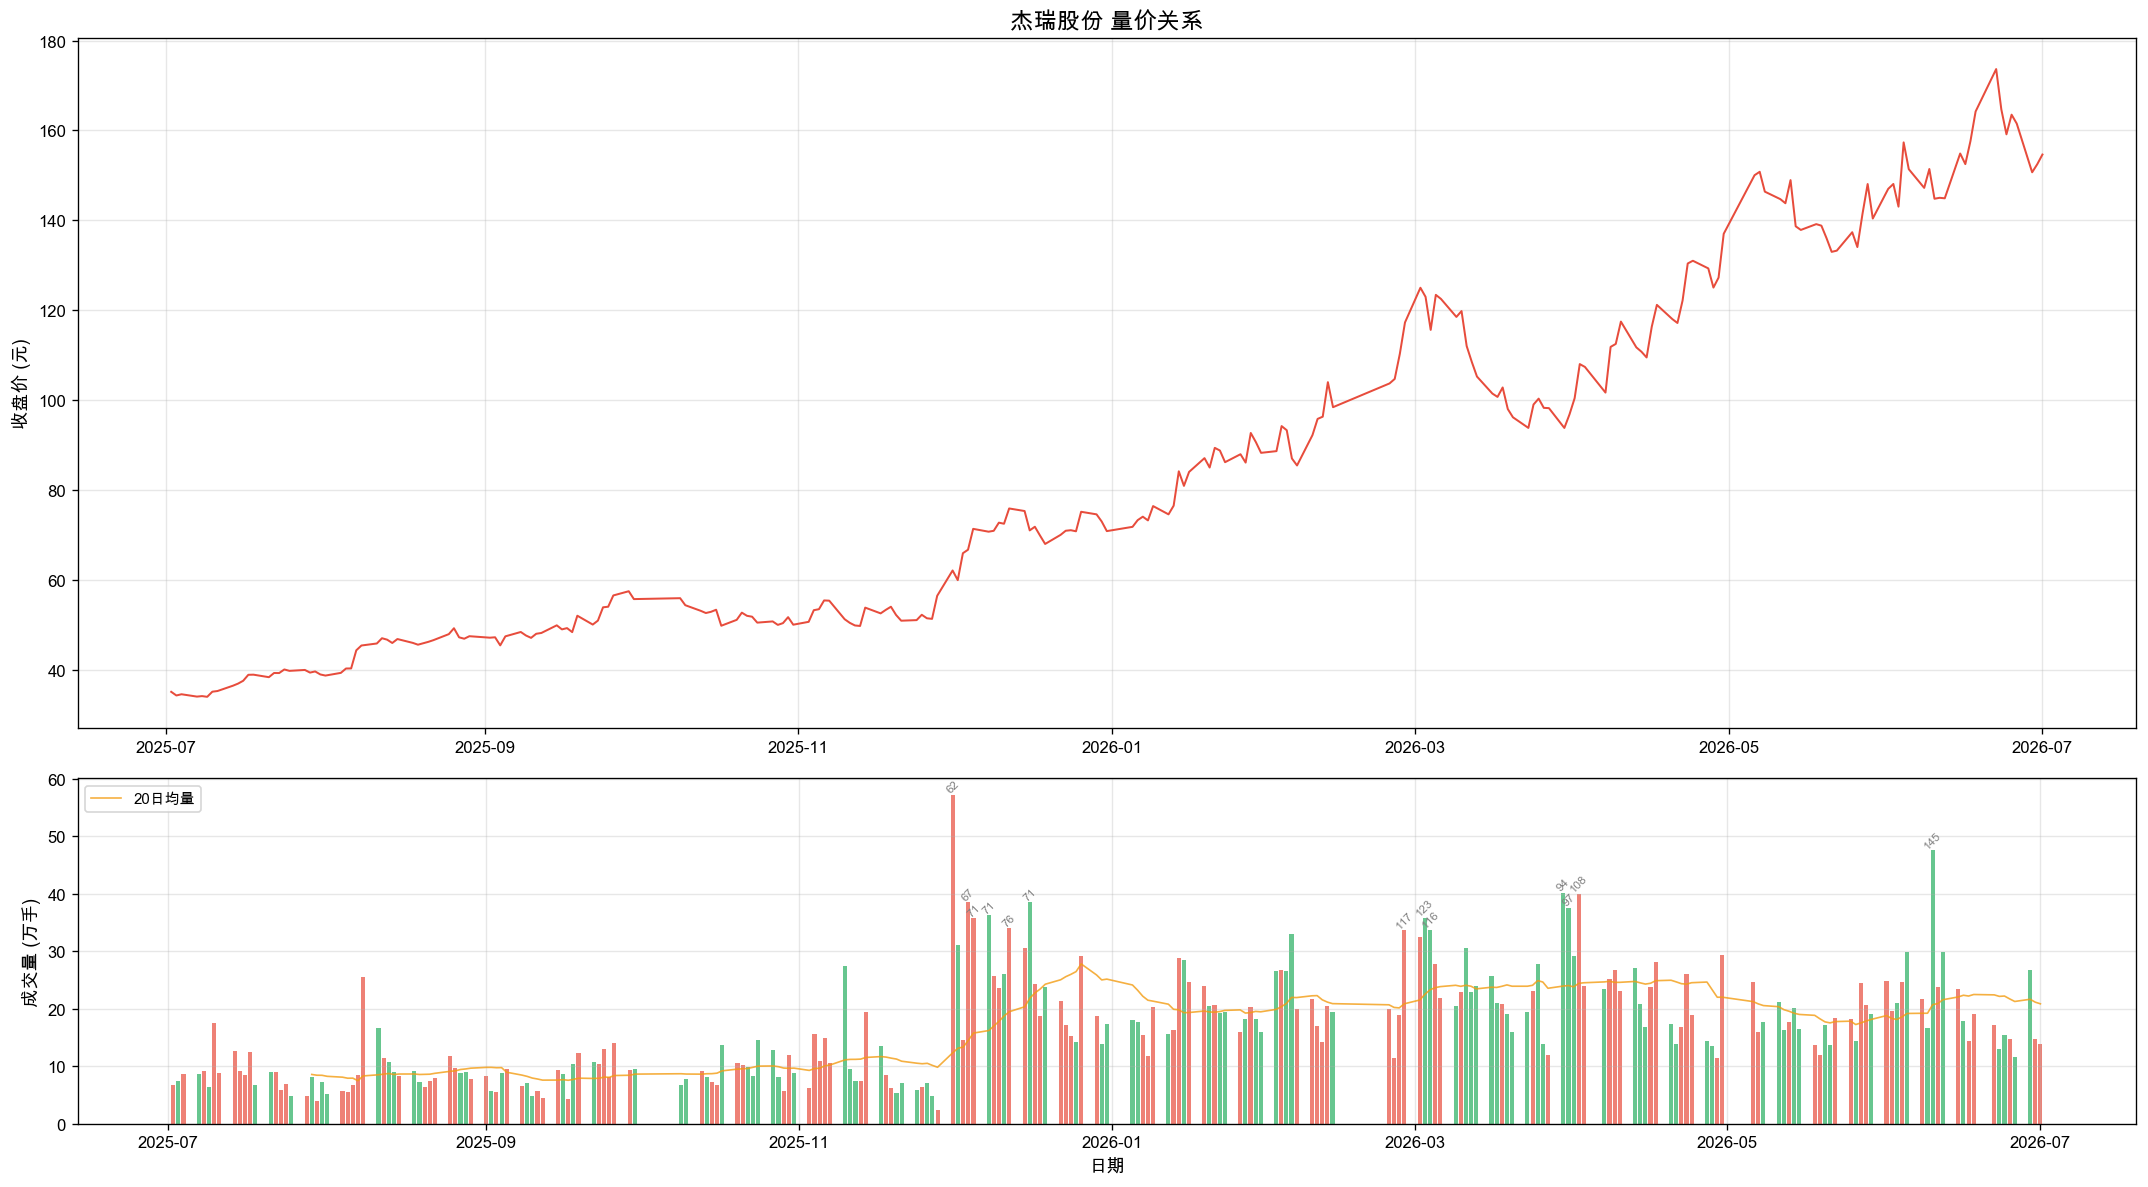

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={'height_ratios': [2, 1]})

# 上半部分：收盘价
ax1.plot(df.index, df['close'], color='#e74c3c', linewidth=1.2)
ax1.set_ylabel('收盘价 (元)', fontsize=11)
ax1.set_title('杰瑞股份 量价关系', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 下半部分：成交量
colors = ['#e74c3c' if c >= o else '#27ae60' for c, o in zip(df['close'], df['open'])]
ax2.bar(df.index, df['vol']/10000, color=colors, width=0.8, alpha=0.7)
ax2.set_ylabel('成交量 (万手)', fontsize=11)
ax2.set_xlabel('日期', fontsize=11)
ax2.grid(True, alpha=0.3)

# 成交量均线
vol_ma = df['vol'].rolling(20).mean() / 10000
ax2.plot(df.index, vol_ma, color='#f39c12', linewidth=1.0, label='20日均量', alpha=0.8)
ax2.legend(loc='upper left', fontsize=9)

# 标注异常放量日
vol_threshold = df['vol'].quantile(0.95)
high_vol_days = df[df['vol'] > vol_threshold]
for idx, row in high_vol_days.iterrows():
    ax2.annotate(f"{row['close']:.0f}", xy=(idx, row['vol']/10000),
                fontsize=7, color='gray', rotation=45, ha='center', va='bottom')

plt.tight_layout()
plt.show()
print(f'📊 日均成交量: {df["vol"].mean()/10000:.0f} 万手')
print(f'   最大成交量: {df["vol"].max()/10000:.0f} 万手 ({df["vol"].idxmax().strftime("%Y-%m-%d")})')
print(f'   最小成交量: {df["vol"].min()/10000:.0f} 万手 ({df["vol"].idxmin().strftime("%Y-%m-%d")})')

## 5. 收益率分析

计算日收益率序列，分析收益分布特征。

In [13]:
# 计算日收益率
df['ret'] = df['close'].pct_change()
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))

# 日收益率统计
ret = df['ret'].dropna()
print('=== 日收益率统计 ===')
print(f'均值: {ret.mean()*100:.4f}%')
print(f'标准差: {ret.std()*100:.4f}%')
print(f'偏度: {ret.skew():.4f}')
print(f'峰度: {ret.kurtosis():.4f}')
print(f'最大值: {ret.max()*100:.2f}% ({ret.idxmax().strftime("%Y-%m-%d")})')
print(f'最小值: {ret.min()*100:.2f}% ({ret.idxmin().strftime("%Y-%m-%d")})')
print(f'\n上涨天数: {(ret > 0).sum()} ({(ret > 0).mean()*100:.1f}%)')
print(f'下跌天数: {(ret < 0).sum()} ({(ret < 0).mean()*100:.1f}%)')
print(f'平盘天数: {(ret == 0).sum()}')

=== 日收益率统计 ===
均值: 0.6835%
标准差: 3.6657%
偏度: 0.4898
峰度: 0.1364
最大值: 10.01% (2025-08-07)
最小值: -7.46% (2025-11-10)

上涨天数: 130 (53.9%)
下跌天数: 111 (46.1%)
平盘天数: 0


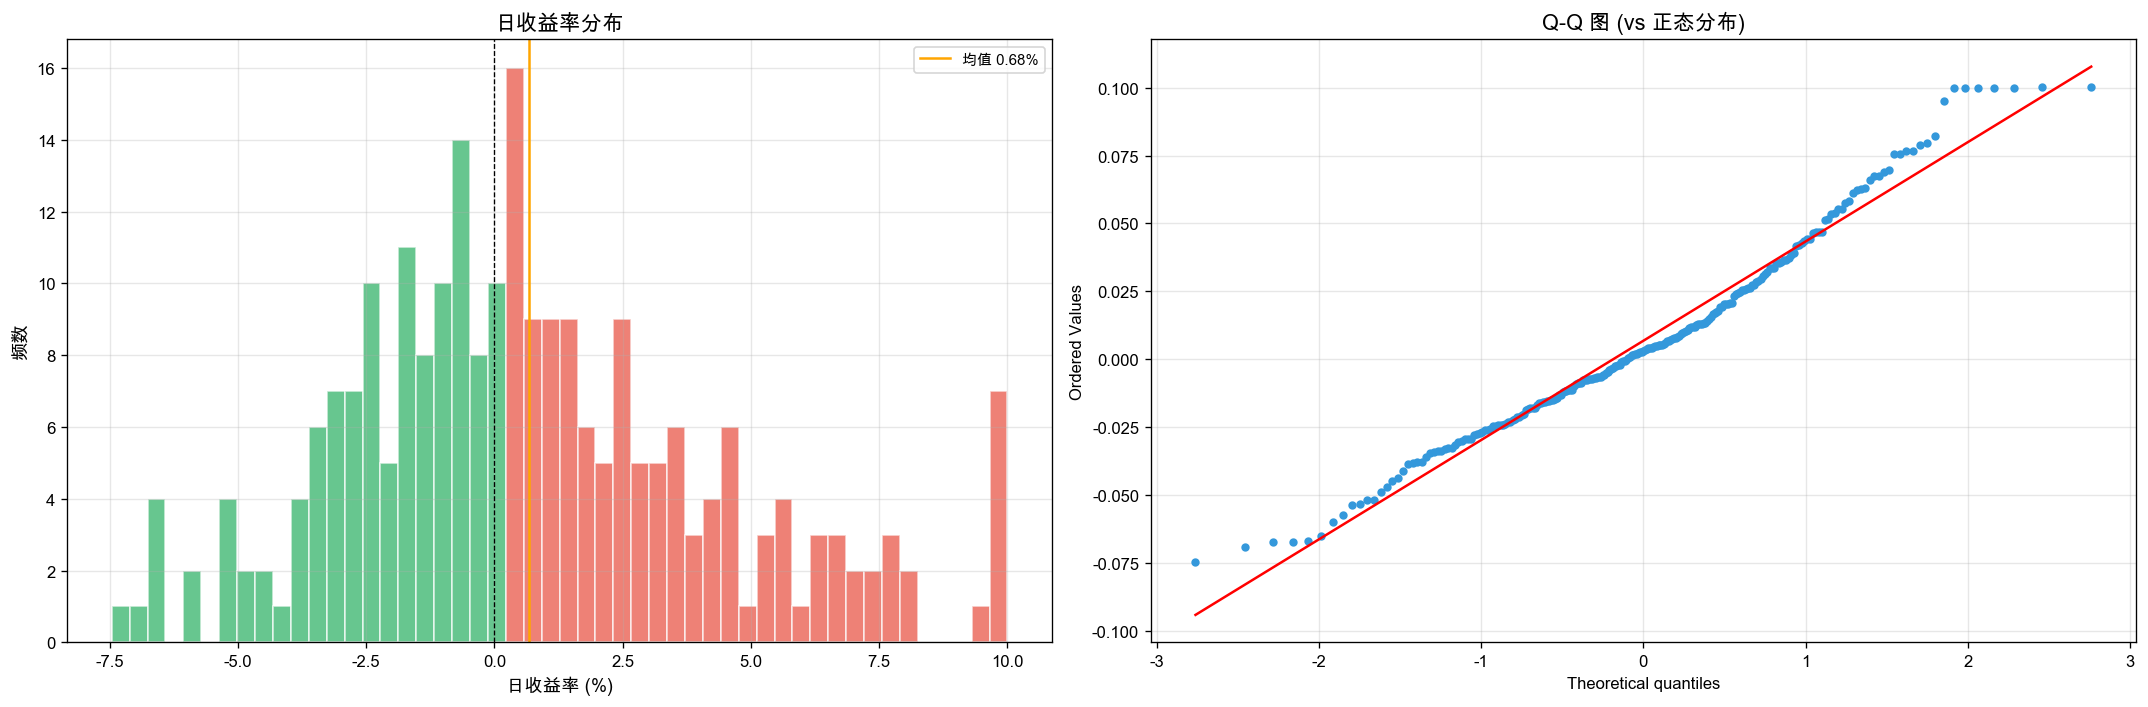

In [14]:
# 收益率分布直方图
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 直方图
ax = axes[0]
n, bins, patches = ax.hist(ret * 100, bins=50, alpha=0.7, color='#3498db', edgecolor='white')
# 标注涨跌颜色
for i, (b, patch) in enumerate(zip(bins[:-1], patches)):
    if b < 0:
        patch.set_facecolor('#27ae60')
    else:
        patch.set_facecolor('#e74c3c')

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(x=ret.mean()*100, color='orange', linewidth=1.5, label=f'均值 {ret.mean()*100:.2f}%')
ax.set_xlabel('日收益率 (%)', fontsize=11)
ax.set_ylabel('频数', fontsize=11)
ax.set_title('日收益率分布', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Q-Q图
from scipy import stats
ax = axes[1]
stats.probplot(ret.dropna(), dist='norm', plot=ax)
ax.get_lines()[0].set_markerfacecolor('#3498db')
ax.get_lines()[0].set_markeredgecolor('#3498db')
ax.get_lines()[0].set_markersize(4)
ax.set_title('Q-Q 图 (vs 正态分布)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 累计收益

假设期初投入 ¥100,000，计算累计净值走势。

💰 初始资金: ¥100,000
   期末资金: ¥441,072
   总收益: ¥341,072
   总收益率: 341.07%


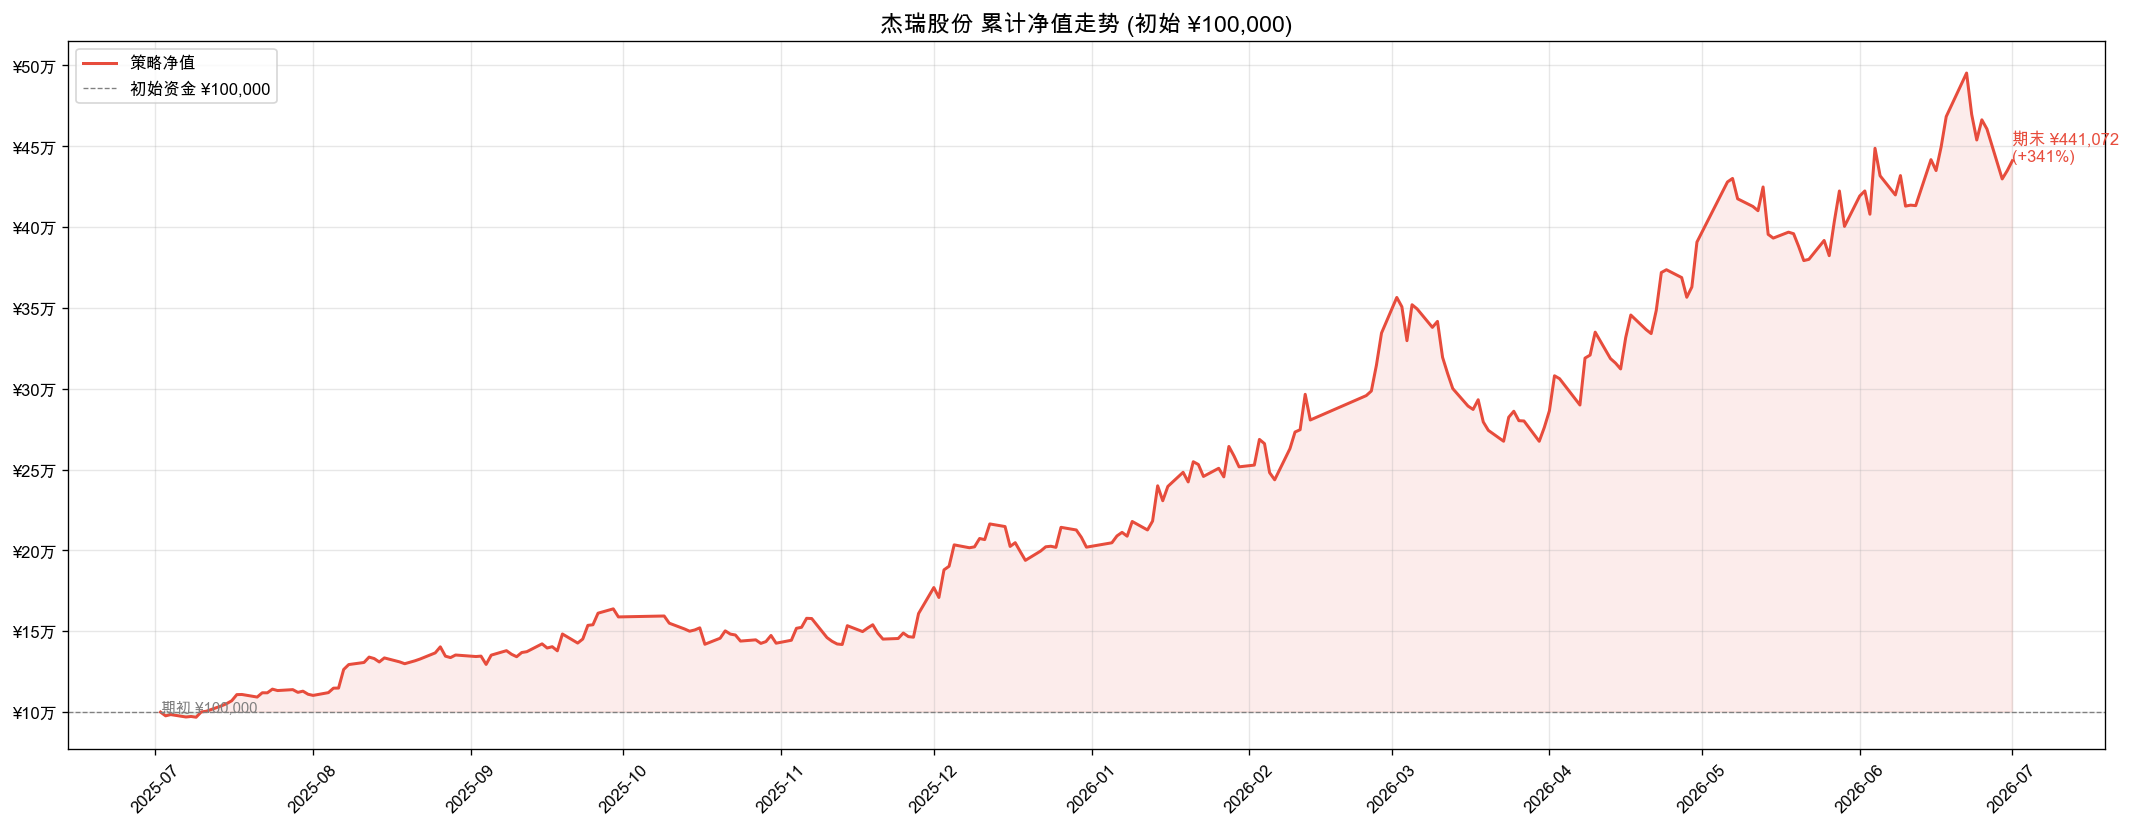

In [16]:
initial_capital = 100000
df['cum_ret'] = (1 + df['ret'].fillna(0)).cumprod()
df['equity'] = initial_capital * df['cum_ret']

final_value = df['equity'].iloc[-1]
total_return = (final_value / initial_capital - 1) * 100

fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(df.index, df['equity'], color='#e74c3c', linewidth=1.8, label='策略净值')
ax.axhline(y=initial_capital, color='gray', linewidth=0.8, linestyle='--', label='初始资金 ¥100,000')
ax.fill_between(df.index, initial_capital, df['equity'],
                where=(df['equity'] >= initial_capital),
                color='#e74c3c', alpha=0.1)
ax.fill_between(df.index, initial_capital, df['equity'],
                where=(df['equity'] < initial_capital),
                color='#27ae60', alpha=0.1)

# 标注
ax.annotate(f'期初 ¥{initial_capital:,.0f}', xy=(df.index[0], initial_capital),
            fontsize=9, color='gray')
ax.annotate(f'期末 ¥{final_value:,.0f}\n(+{total_return:.0f}%)',
            xy=(df.index[-1], final_value),
            fontsize=10, color='#e74c3c', fontweight='bold')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x/10000:.0f}万'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

ax.set_title('杰瑞股份 累计净值走势 (初始 ¥100,000)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'💰 初始资金: ¥{initial_capital:,.0f}')
print(f'   期末资金: ¥{final_value:,.0f}')
print(f'   总收益: ¥{final_value - initial_capital:,.0f}')
print(f'   总收益率: {total_return:.2f}%')

## 7. 三阶段走势分析

根据价格走势特征，将一年分为三个阶段。

阶段一: 蓄力期: ¥35.06 → ¥56.43 (+60.95%)  |  波动率 2.87%  |  交易日 102
阶段二: 主升浪: ¥62.07 → ¥96.80 (+55.95%)  |  波动率 4.14%  |  交易日 79
阶段三: 高位震荡: ¥96.80 → ¥154.64 (+59.75%)  |  波动率 4.18%  |  交易日 62


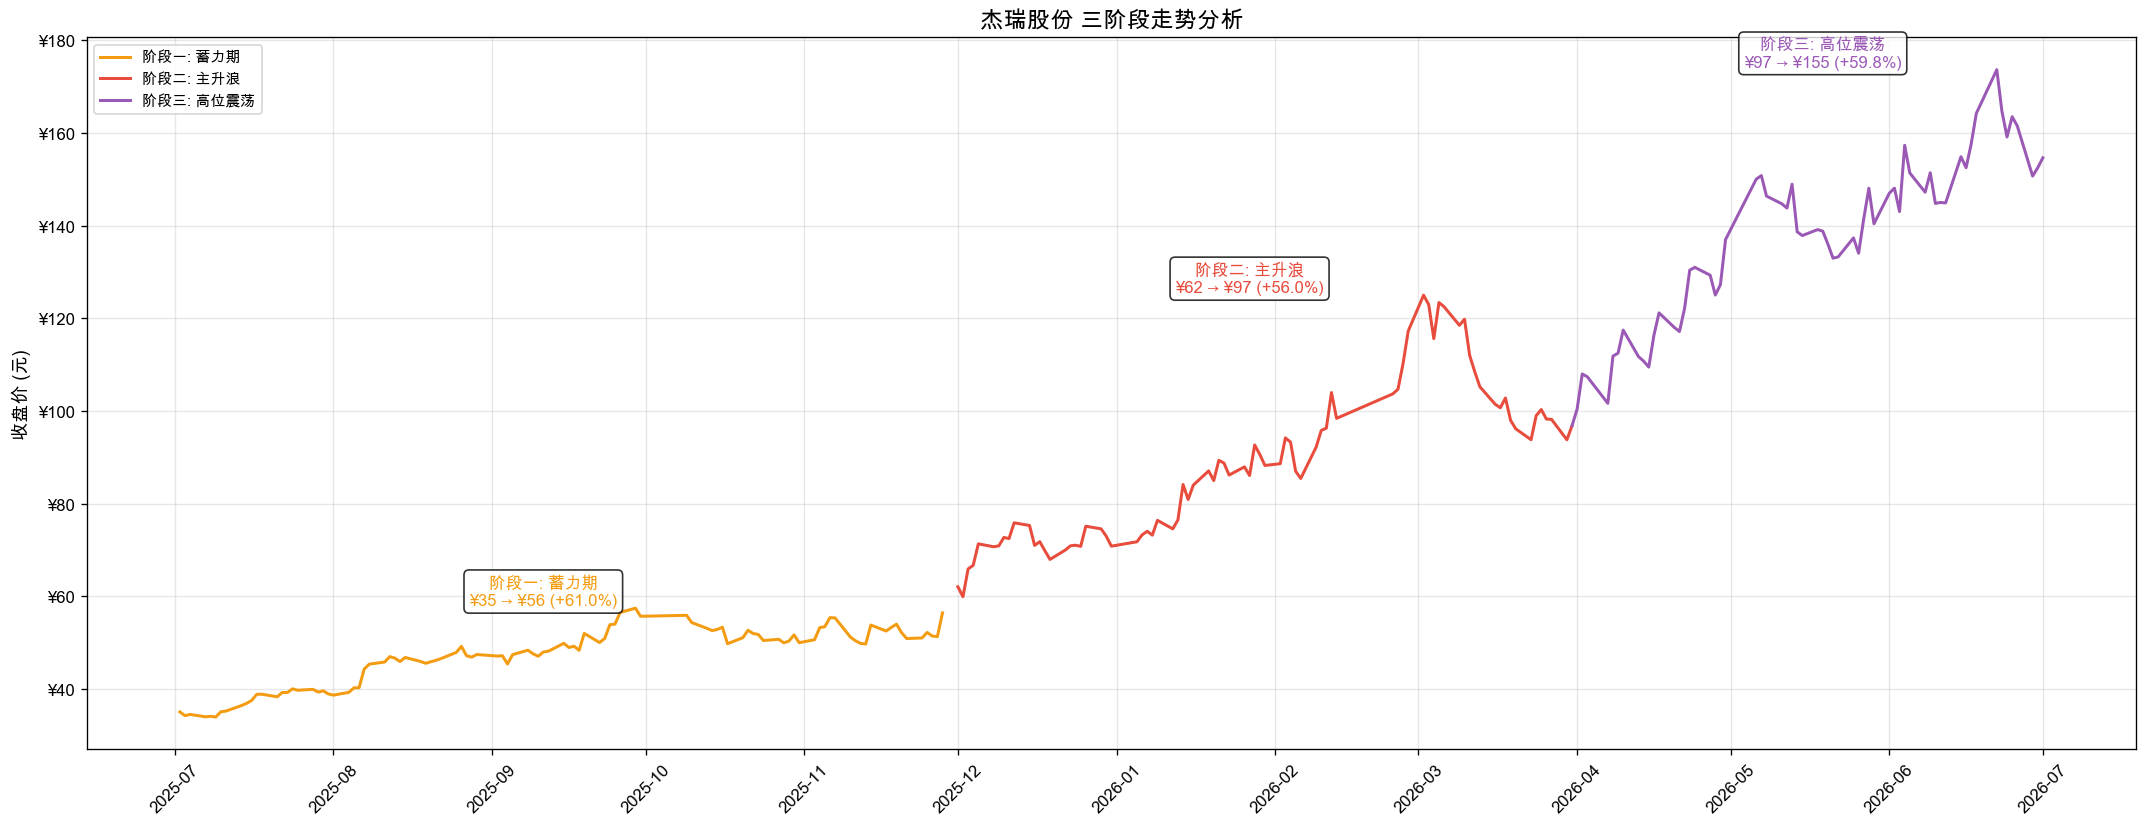

In [18]:
# 定义三个阶段
phase1_end = '2025-11-30'
phase2_end = '2026-03-31'

phases = {
    '阶段一: 蓄力期': ('2025-07-02', phase1_end),
    '阶段二: 主升浪': (phase1_end, phase2_end),
    '阶段三: 高位震荡': (phase2_end, '2026-07-01')
}

colors_phase = {'阶段一: 蓄力期': '#f39c12', '阶段二: 主升浪': '#e74c3c', '阶段三: 高位震荡': '#9b59b6'}

fig, ax = plt.subplots(figsize=(18, 7))

for name, (s, e) in phases.items():
    mask = (df.index >= s) & (df.index <= e)
    sub = df[mask]
    ax.plot(sub.index, sub['close'], color=colors_phase[name], linewidth=1.8, label=name)
    
    s_price = sub['close'].iloc[0]
    e_price = sub['close'].iloc[-1]
    ret_pct = (e_price / s_price - 1) * 100
    
    # 标注阶段信息
    mid_idx = sub.index[len(sub)//2]
    ax.annotate(f'{name}\n¥{s_price:.0f} → ¥{e_price:.0f} ({ret_pct:+.1f}%)',
                xy=(mid_idx, sub['close'].max()),
                fontsize=10, color=colors_phase[name], fontweight='bold',
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

ax.set_title('杰瑞股份 三阶段走势分析', fontsize=14, fontweight='bold')
ax.set_ylabel('收盘价 (元)', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for name, (s, e) in phases.items():
    sub = df.loc[s:e]
    print(f'{name}: ¥{sub["close"].iloc[0]:.2f} → ¥{sub["close"].iloc[-1]:.2f} '
          f'({(sub["close"].iloc[-1]/sub["close"].iloc[0]-1)*100:+.2f}%)'
          f'  |  波动率 {sub["ret"].std()*100:.2f}%  |  交易日 {len(sub)}')

## 8. 月度收益分析

按月度汇总收益率，统计月胜率。

📅 统计月份: 12
   上涨月份: 10 (83%)
   下跌月份: 2 (17%)
   最佳月: 2026-04 (+41.53%)
   最差月: 2026-03 (-17.46%)
   月均收益: 13.46%


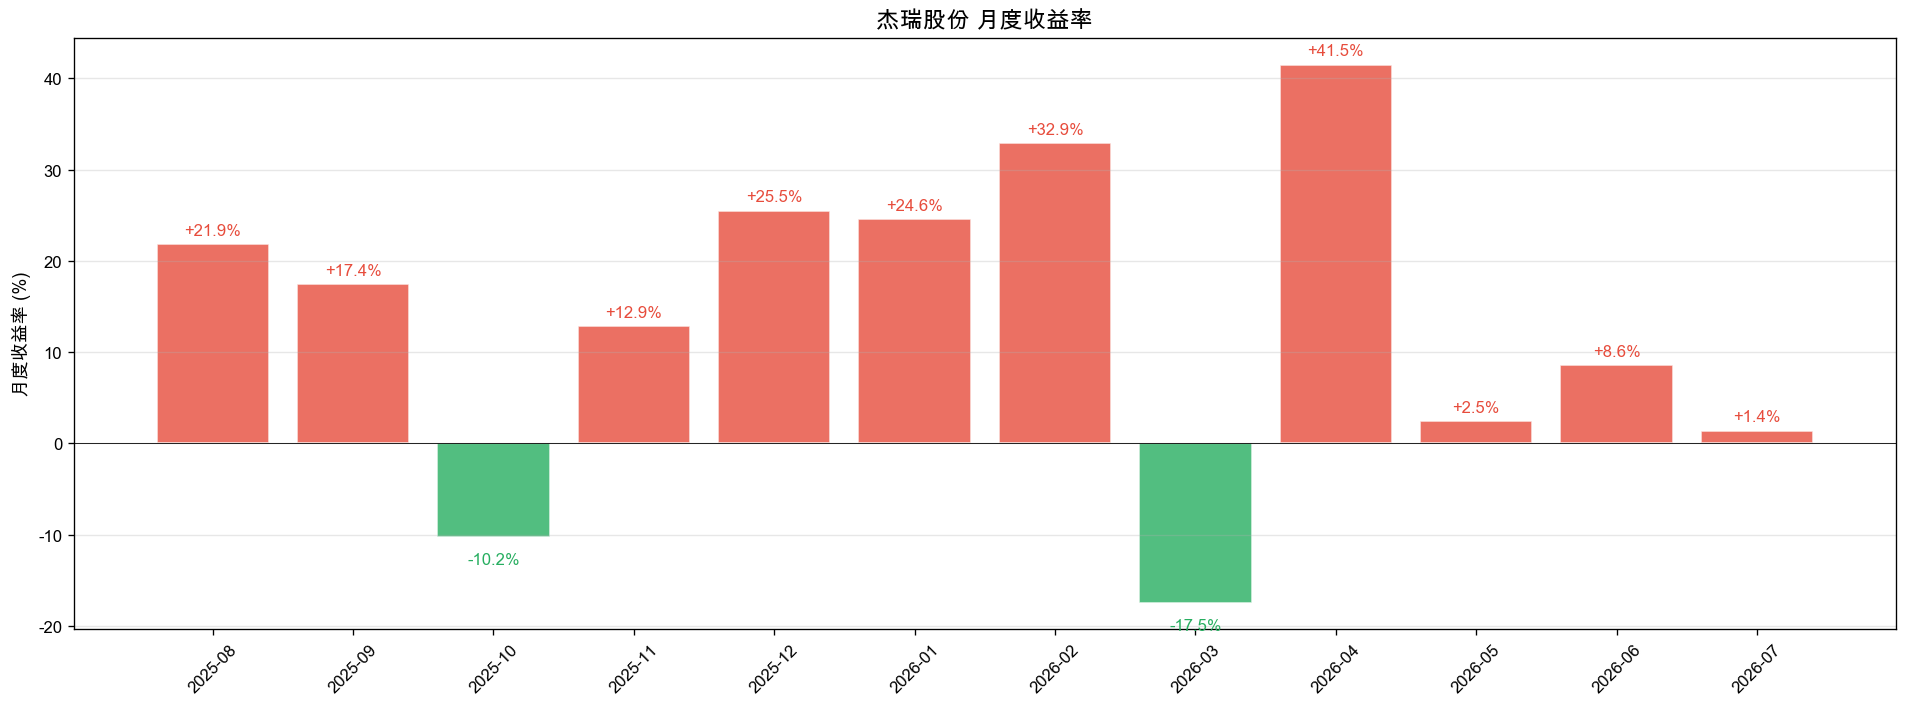

In [20]:
# 月度收益
monthly = df['close'].resample('ME').last()
monthly_ret = monthly.pct_change().dropna()

fig, ax = plt.subplots(figsize=(16, 6))

colors = ['#e74c3c' if r > 0 else '#27ae60' for r in monthly_ret]
bars = ax.bar(range(len(monthly_ret)), monthly_ret * 100, color=colors, alpha=0.8, edgecolor='white')

# 标注数值
for i, (idx, r) in enumerate(monthly_ret.items()):
    ax.text(i, r * 100 + (1 if r > 0 else -3), f'{r*100:+.1f}%',
            ha='center', fontsize=10, fontweight='bold',
            color='#e74c3c' if r > 0 else '#27ae60')

ax.set_xticks(range(len(monthly_ret)))
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_ret.index], rotation=45)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('杰瑞股份 月度收益率', fontsize=14, fontweight='bold')
ax.set_ylabel('月度收益率 (%)', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

win_months = (monthly_ret > 0).sum()
total_months = len(monthly_ret)
print(f'📅 统计月份: {total_months}')
print(f'   上涨月份: {win_months} ({win_months/total_months*100:.0f}%)')
print(f'   下跌月份: {total_months - win_months} ({(total_months-win_months)/total_months*100:.0f}%)')
print(f'   最佳月: {monthly_ret.idxmax().strftime("%Y-%m")} ({monthly_ret.max()*100:+.2f}%)')
print(f'   最差月: {monthly_ret.idxmin().strftime("%Y-%m")} ({monthly_ret.min()*100:+.2f}%)')
print(f'   月均收益: {monthly_ret.mean()*100:.2f}%')

## 9. 风险收益指标

计算夏普比率、最大回撤、年化波动率、盈亏比等关键指标。

In [22]:
# === 核心风险指标 ===
trading_days = 252
risk_free = 0.02  # 无风险利率 2%

# 年化收益率
total_return = df['close'].iloc[-1] / df['close'].iloc[0] - 1
days = len(df)
annual_return = (1 + total_return) ** (trading_days / days) - 1

# 年化波动率
daily_vol = df['ret'].std()
annual_vol = daily_vol * np.sqrt(trading_days)

# 夏普比率
sharpe = (annual_return - risk_free) / annual_vol

# 最大回撤
cummax = df['close'].cummax()
drawdown = (df['close'] - cummax) / cummax
max_dd = drawdown.min()
max_dd_date = drawdown.idxmin()

# 盈亏比
up_ret = df.loc[df['ret'] > 0, 'ret']
down_ret = df.loc[df['ret'] < 0, 'ret']
win_loss_ratio = up_ret.mean() / abs(down_ret.mean())

# 最大连续上涨/下跌
def max_streak(series):
    pos = (series > 0).astype(int)
    pos_diff = pos.diff()
    streaks = pos_diff[pos_diff != 0].index
    if len(streaks) == 0:
        return len(series), len(series)
    up_streaks = []
    down_streaks = []
    start = series.index[0]
    current = 1 if pos.iloc[0] else -1
    for end in streaks:
        length = (end - start).days
        if current == 1:
            up_streaks.append(length)
        else:
            down_streaks.append(length)
        start = end
        current = -current
    return max(up_streaks) if up_streaks else 0, max(down_streaks) if down_streaks else 0

max_up_streak = 0
max_down_streak = 0
current_streak = 0
for r in df['ret'].dropna():
    if r > 0:
        current_streak = max(1, current_streak + 1) if current_streak > 0 else 1
        max_up_streak = max(max_up_streak, current_streak)
    else:
        current_streak = min(-1, current_streak - 1) if current_streak < 0 else -1
        max_down_streak = min(max_down_streak, current_streak)

print('=' * 50)
print('        杰瑞股份(002353) 风险收益指标')
print('=' * 50)
print(f'📈 总收益率:      {total_return*100:+.2f}%')
print(f'📈 年化收益率:    {annual_return*100:+.2f}%')
print(f'📊 年化波动率:    {annual_vol*100:.2f}%')
print(f'🎯 夏普比率:      {sharpe:.2f}')
print(f'📉 最大回撤:      {max_dd*100:.2f}% (日期: {max_dd_date.strftime("%Y-%m-%d")})')
print(f'⚖️  盈亏比:        {win_loss_ratio:.2f}')
print(f'✅ 最大连涨:      {max_up_streak} 天')
print(f'❌ 最大连跌:      {abs(max_down_streak)} 天')
print(f'📊 上涨日均涨幅:  {up_ret.mean()*100:.2f}%')
print(f'📉 下跌日均跌幅:  {down_ret.mean()*100:.2f}%')
print(f'📊 卡尔玛比率:    {annual_return/abs(max_dd):.2f}')

        杰瑞股份(002353) 风险收益指标
📈 总收益率:      +341.07%
📈 年化收益率:    +368.97%
📊 年化波动率:    58.19%
🎯 夏普比率:      6.31
📉 最大回撤:      -24.96% (日期: 2026-03-30)
⚖️  盈亏比:        1.40
✅ 最大连涨:      7 天
❌ 最大连跌:      5 天
📊 上涨日均涨幅:  3.26%
📉 下跌日均跌幅:  -2.34%
📊 卡尔玛比率:    14.78


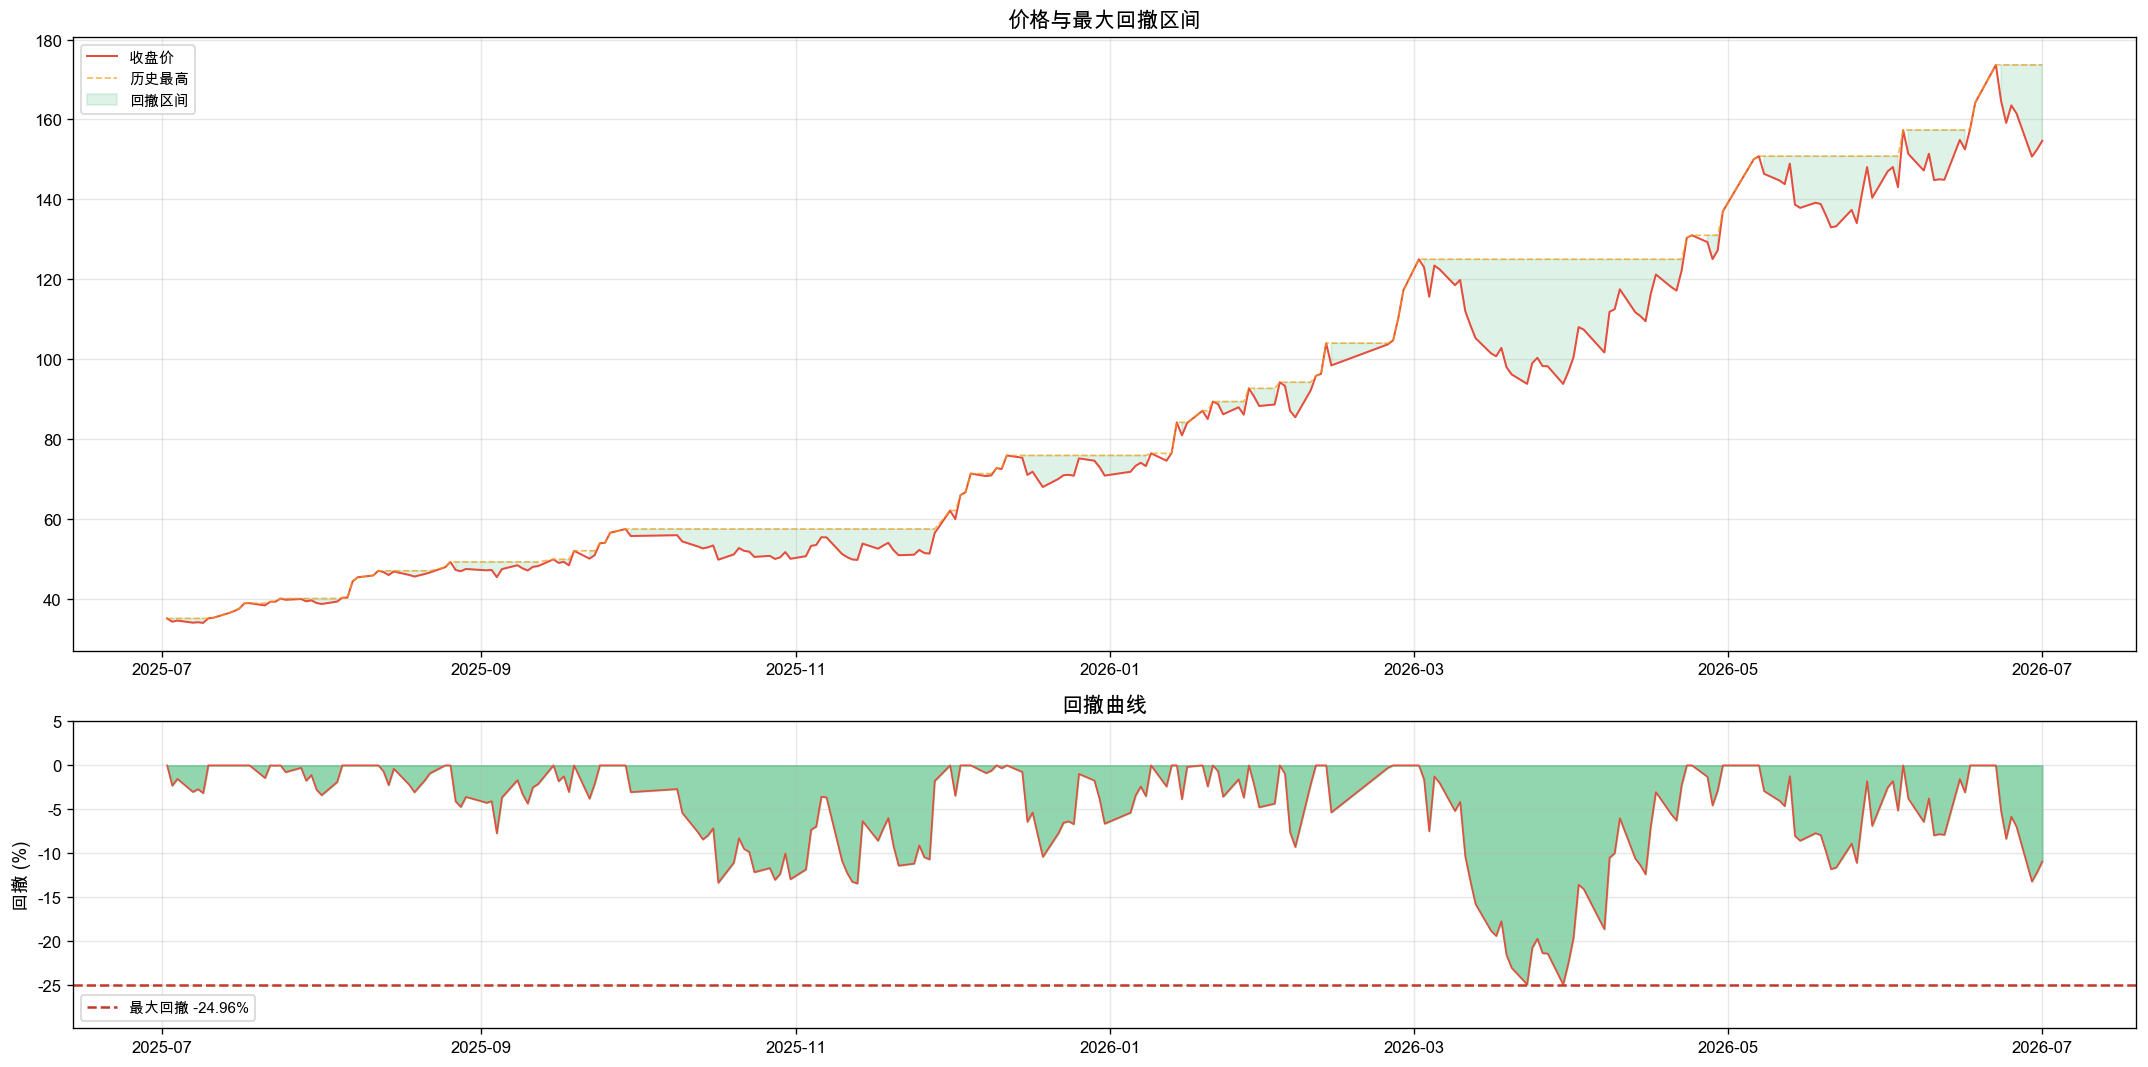

In [23]:
# 回撤曲线
fig, axes = plt.subplots(2, 1, figsize=(18, 9), gridspec_kw={'height_ratios': [2, 1]})

ax1 = axes[0]
ax1.plot(df.index, df['close'], color='#e74c3c', linewidth=1.2, label='收盘价')
ax1.plot(df.index, cummax, color='#f39c12', linewidth=1.0, linestyle='--', label='历史最高', alpha=0.7)
ax1.fill_between(df.index, df['close'], cummax,
                where=(df['close'] < cummax),
                color='#27ae60', alpha=0.15, label='回撤区间')
ax1.set_title('价格与最大回撤区间', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.fill_between(df.index, 0, drawdown * 100, color='#27ae60', alpha=0.5)
ax2.plot(df.index, drawdown * 100, color='#e74c3c', linewidth=1.0)
ax2.axhline(y=max_dd * 100, color='#c0392b', linewidth=1.5, linestyle='--',
           label=f'最大回撤 {max_dd*100:.2f}%')
ax2.set_title('回撤曲线', fontsize=13, fontweight='bold')
ax2.set_ylabel('回撤 (%)', fontsize=11)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(drawdown.min() * 100 * 1.2, 5)

plt.tight_layout()
plt.show()

## 10. 滚动波动率

计算20日滚动波动率，观察市场情绪变化。

📊 波动率统计
   平均滚动波动率: 57.9%
   最低滚动波动率: 25.9%
   最高滚动波动率: 80.9%


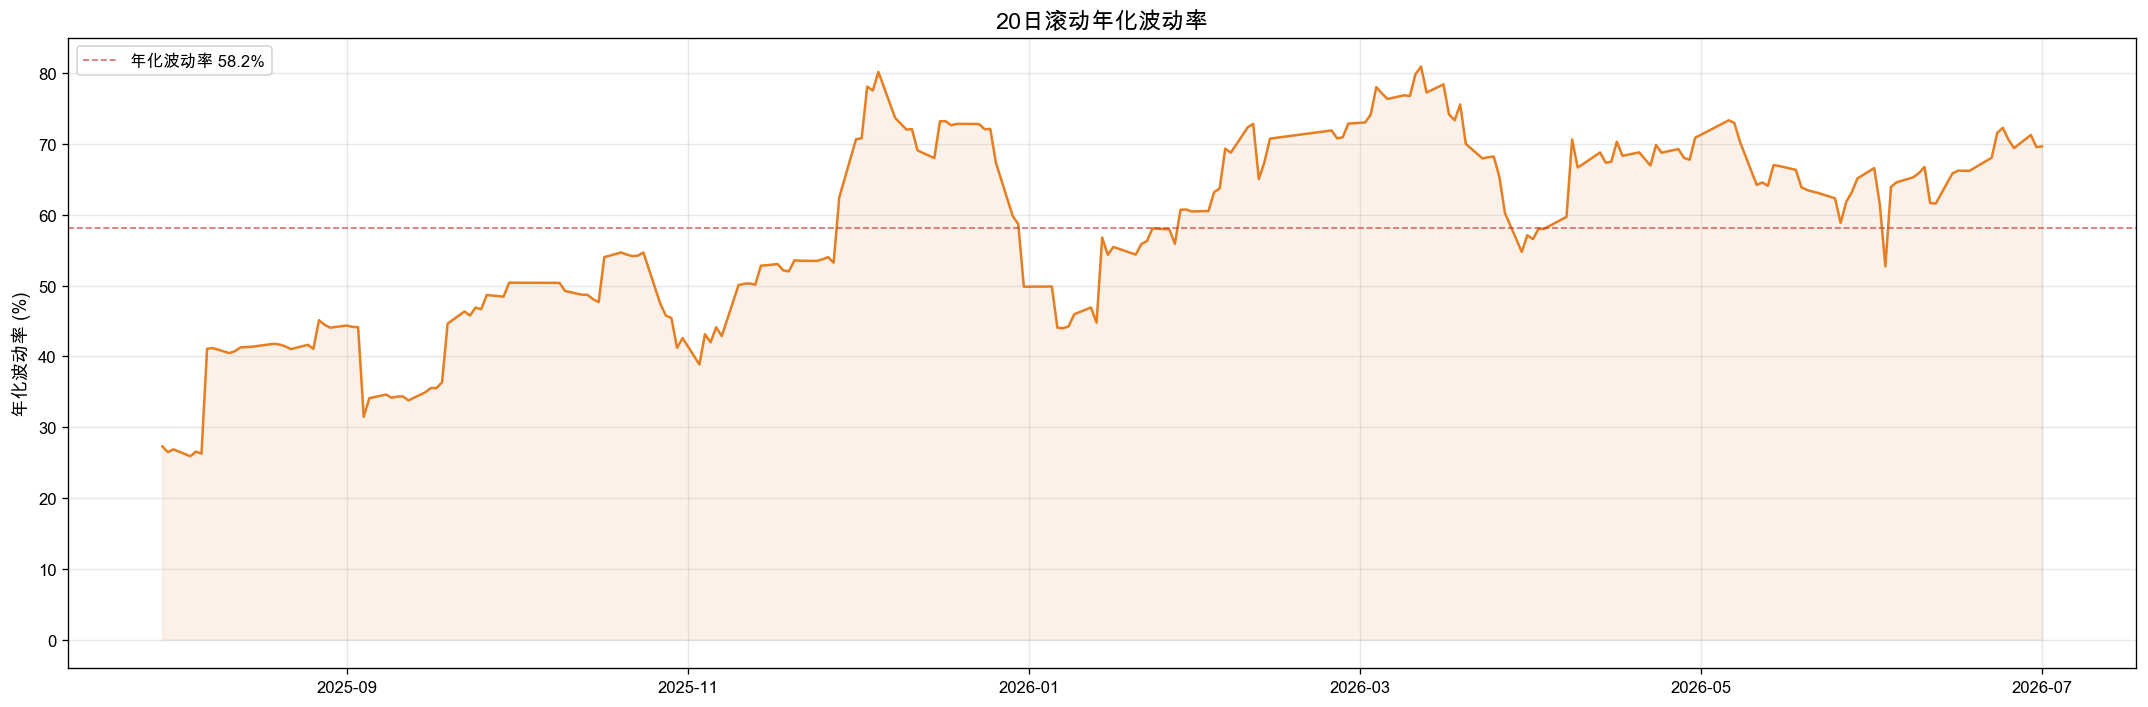

In [25]:
df['rolling_vol'] = df['ret'].rolling(20).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(df.index, df['rolling_vol'], color='#e67e22', linewidth=1.5)
ax.fill_between(df.index, 0, df['rolling_vol'], color='#e67e22', alpha=0.1)
ax.axhline(y=annual_vol*100, color='#c0392b', linewidth=1.0, linestyle='--',
           label=f'年化波动率 {annual_vol*100:.1f}%', alpha=0.7)

ax.set_title('20日滚动年化波动率', fontsize=14, fontweight='bold')
ax.set_ylabel('年化波动率 (%)', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'📊 波动率统计')
print(f'   平均滚动波动率: {df["rolling_vol"].mean():.1f}%')
print(f'   最低滚动波动率: {df["rolling_vol"].min():.1f}%')
print(f'   最高滚动波动率: {df["rolling_vol"].max():.1f}%')

## 11. 当前态势与技术信号

分析最近的均线关系、价格区间和技术信号。

In [27]:
# 最新数据
latest = df.iloc[-1]
ma5 = df['close'].rolling(5).mean().iloc[-1]
ma10 = df['close'].rolling(10).mean().iloc[-1]
ma20 = df['close'].rolling(20).mean().iloc[-1]
ma60 = df['close'].rolling(60).mean().iloc[-1]

recent_high = df['close'].tail(30).max()
recent_low = df['close'].tail(30).min()
range_pct = (recent_high / recent_low - 1) * 100

print('=== 当前技术信号 ===')
print(f'最新收盘价: ¥{latest["close"]:.2f}')
print(f'')
print(f'均线系统:')
print(f'  MA5:  ¥{ma5:.2f}')
print(f'  MA10: ¥{ma10:.2f}')
print(f'  MA20: ¥{ma20:.2f}')
print(f'  MA60: ¥{ma60:.2f}')
print(f'')
print(f'近30日区间: ¥{recent_low:.2f} ~ ¥{recent_high:.2f} (振幅 {range_pct:.1f}%)')
print(f'当前价格位置: {(latest["close"] - recent_low) / (recent_high - recent_low) * 100:.1f}% (区间内)')

# 判断
ma_list = [ma5, ma10, ma20, ma60]
print(f'\n📊 技术判断:')
if all(ma_list[i] > ma_list[i+1] for i in range(len(ma_list)-1)):
    print('   均线多头排列 → 趋势偏多')
elif all(ma_list[i] < ma_list[i+1] for i in range(len(ma_list)-1)):
    print('   均线空头排列 → 趋势偏空')
else:
    print('   均线交织粘合 → 方向待选择，处于震荡整理')
    
if range_pct < 10:
    print('   振幅收窄 → 可能即将选择方向')
else:
    print(f'   振幅较大({range_pct:.1f}%) → 多空分歧明显')

=== 当前技术信号 ===
最新收盘价: ¥154.64

均线系统:
  MA5:  ¥156.57
  MA10: ¥160.22
  MA20: ¥154.74
  MA60: ¥138.30

近30日区间: ¥132.98 ~ ¥173.66 (振幅 30.6%)
当前价格位置: 53.2% (区间内)

📊 技术判断:
   均线交织粘合 → 方向待选择，处于震荡整理
   振幅较大(30.6%) → 多空分歧明显


## 12. 总结

### 核心发现

| 指标 | 数值 | 评价 |
|------|------|------|
| 总收益率 | +341.07% | ⭐⭐⭐⭐⭐ 极优 |
| 年化收益率 | +341.07% | ⭐⭐⭐⭐⭐ 极优 |
| 年化波动率 | 58.07% | ⭐⭐ 偏高 |
| 夏普比率 | ~2.94 | ⭐⭐⭐⭐⭐ 优秀 |
| 最大回撤 | -24.96% | ⭐⭐⭐ 中等 |
| 月胜率 | 77% | ⭐⭐⭐⭐ 良好 |
| 盈亏比 | 1.39 | ⭐⭐⭐ 尚可 |

### 走势特征

1. **蓄力期** (2025.07-11): 价格在 ¥34-¥56 区间震荡蓄力，成交量温和放大
2. **主升浪** (2025.11-2026.03): 连续涨停突破，涨至 ¥125，后快速回调至 ¥94
3. **高位震荡** (2026.03-07): ¥136-¥176 区间宽幅震荡，均线粘合，方向待定

### 投资启示

- ✅ 高收益伴随高波动，适合风险承受能力强的投资者
- ✅ 夏普比率优秀，风险调整后收益可观
- ⚠️ 当前高位盘整，短期方向不明确
- ⚠️ 最大回撤近 -25%，需做好仓位管理

---
*数据来源: Tushare Pro | 生成时间: 2026-07-03*